<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import textstat
import kagglehub
import os
import warnings


# Data Preparation & Preprocessing


In [ ]:
warnings.filterwarnings("ignore")

print("Downloading ISOT dataset...")
path = kagglehub.dataset_download("rahulogoel/isot-fake-news-dataset")

data_dir = os.path.join(path, "News_Dataset")
print("Loading ISOT dataset...")
true_df = pd.read_csv(os.path.join(data_dir, "True.csv"))
fake_df = pd.read_csv(os.path.join(data_dir, "Fake.csv"))

def preprocess_isot(df, is_fake):
  df = df.dropna(subset=['text'])
  df['text'] = df['text'].astype(str)

  def clean_text(text):
    if not is_fake:
      text = re.sub(r'^.*?\(Reuters\)\s*-\s*', '', text)
    return text.strip()

  df['text'] = df['text'].apply(clean_text)
  return df[df['text'].str.strip() != ""]

true_df = preprocess_isot(true_df, is_fake=False)
fake_df = preprocess_isot(fake_df, is_fake=True)

true_df = true_df.sample(n=5000, random_state=42)
fake_df = fake_df.sample(n=5000, random_state=42)

true_df['label'] = 0
fake_df['label'] = 1

df = pd.concat([true_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset is ready! Total numbers of rows: {len(df)}")

100%|██████████| 41.0M/41.0M [00:03<00:00, 11.2MB/s]

Extracting files...


Loading ISOT dataset...
Dataset is ready! Total numbers of rows: 10000


# Feature Engineering

In [ ]:
def extract_linguistic_features(texts):
  features = []
  for text in texts:
    features.append([
        textstat.flesch_reading_ease(text),
        textstat.smog_index(text),
        len(text.split()),
        text.count('!'),
        sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0
    ])
  return np.array(features)

print("Extracting engineered linguistic features for {len(df)} texts...")
ling_features = extract_linguistic_features(df['text'])
print("Feature extraction complete. Shape: ", ling_features.shape)

X_train_text, X_test_text, y_train, y_test, X_train_ling, X_test_ling = train_test_split(
    df['text'], df['label'], ling_features, test_size=0.2, random_state=42, stratify=df['label']
)

Extracting engineered linguistic features for {len(df)} texts...
Feature extraction complete. Shape:  (10000, 5)


# Baseline

Training XGBoost Baseline...

XGBoost Baseline Results:
0.9675
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1000
           1       0.98      0.95      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



<Figure size 800x600 with 0 Axes>

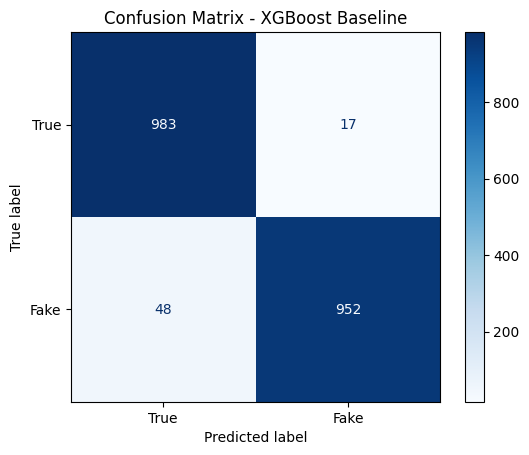

In [ ]:
print("Training XGBoost Baseline...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

X_train_xgb = np.hstack((X_train_tfidf, X_train_ling))
X_test_xgb = np.hstack((X_test_tfidf, X_test_ling))

xgb_model = XGBClassifier(n_estimators=100, learning_rate = 0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb = xgb_model.predict(X_test_xgb)
print("\nXGBoost Baseline Results:")
print(accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'Fake'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - XGBoost Baseline')
plt.show();

# Advanced: RoBERTa Fine-tuning

In [ ]:
print("Fine-tuning RoBERTa (Transfer Learning)...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class FakeNewsDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len=256):
    self.encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=max_len)
    self.labels = labels.tolist()

  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)


def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
  acc = accuracy_score(labels, preds)
  return {
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall
  }

train_dataset = FakeNewsDataset(X_train_text, y_train, tokenizer)
test_dataset = FakeNewsDataset(X_test_text, y_test, tokenizer)

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    weight_decay=0.01,
)

trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Fine-tuning RoBERTa (Transfer Learning)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=0.052145252227783205, metrics={'train_runtime': 990.0767, 'train_samples_per_second': 16.16, 'train_steps_per_second': 2.02, 'total_flos': 2104888442880000.0, 'train_loss': 0.052145252227783205, 'epoch': 2.0})

In [ ]:
eval_results = trainer.evaluate()

print("RoBERTa Results:")
for key, value in eval_results.items():
  print(f"{key}: {value:.4f}")

RoBERTa Results:
eval_loss: 0.0085
eval_accuracy: 0.9980
eval_f1: 0.9980
eval_precision: 0.9970
eval_recall: 0.9990
eval_runtime: 34.6056
eval_samples_per_second: 57.7940
eval_steps_per_second: 7.2240
epoch: 2.0000


# Hybrid Ensemble

In [ ]:
print("Implementing Hybrid Ensemble...")
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
roberta_raw = trainer.predict(test_dataset)
roberta_probs = torch.nn.functional.softmax(torch.tensor(roberta_raw.predictions), dim=1)[:, 1].numpy()

hybrid_probs = (xgb_probs + roberta_probs) / 2
y_pred_hybrid = (hybrid_probs > 0.5).astype(int)

print("\nHybrid Ensamble Results")
print(f"Hybrid Accuracy: {accuracy_score(y_test, y_pred_hybrid):.4f}")
print("\nClassification Report for Hybrid Ensamble")
print(classification_report(y_test, y_pred_hybrid))


Implementing Hybrid Ensemble...



Hybrid Ensamble Results
Hybrid Accuracy: 0.9980

Classification Report for Hybrid Ensamble
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# Evaluation & XAI (SHAP)

Final Results (Hybrid): 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Generating SHAP feautre importance...


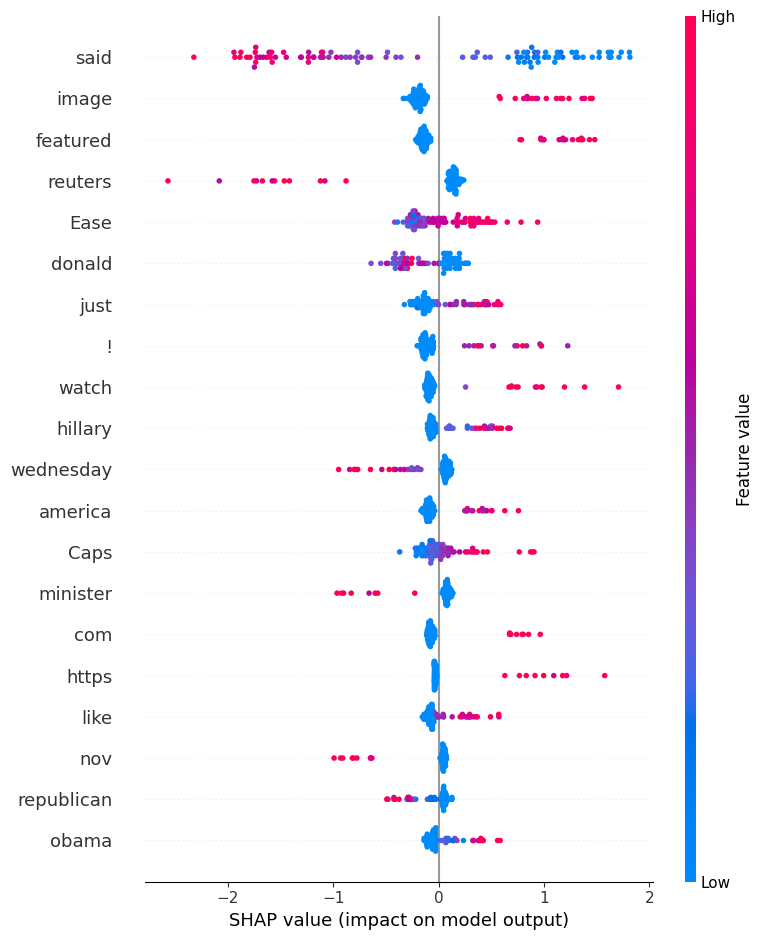

In [ ]:
print("Final Results (Hybrid): ")
print(classification_report(y_test, y_pred_hybrid))

print("Generating SHAP feautre importance...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb[:100])
shap.summary_plot(shap_values, X_test_xgb[:100], feature_names=list(tfidf.get_feature_names_out()) + ['Ease', 'SMOG', 'Words', '!', 'Caps'])
